In [1]:
# Cell 1: Import and setup
from ultralytics import YOLO
import torch

# Check if GPU is available (highly recommended but not required)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Training on CPU - this will be SLOW. Consider using Google Colab for free GPU.")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ayesh\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu
⚠️ Training on CPU - this will be SLOW. Consider using Google Colab for free GPU.


In [2]:
# Cell 2: Load pretrained YOLOv8 classification model
model = YOLO('yolov8n-cls.pt')  # nano model (smallest, fastest)

print("✅ Model loaded!")
print(f"Model type: Classification")
print(f"Model size: Nano (fastest)")

✅ Model loaded!
Model type: Classification
Model size: Nano (fastest)


In [3]:
# Cell 3: Train the model
results = model.train(
    data='datasets/plantvillage_yolo',  # path to your split dataset
    epochs=20,                           # number of training cycles (start small)
    imgsz=224,                          # image size
    batch=16,                           # batch size (reduce if out of memory)
    patience=5,                         # early stopping patience
    device=device,                      # use GPU if available
    project='runs/classify',            # where to save results
    name='plant_disease_v1',            # experiment name
    plots=True,                         # generate plots
    verbose=True                        # show detailed output
)

print("\n Training complete!")

Ultralytics 8.3.217  Python-3.13.7 torch-2.9.0+cpu CPU (Intel Core i7-14700KF)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/plantvillage_yolo, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=plant_disease_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspective=0.0, plots=True, 

In [1]:
# Cell 1: Load your trained model
from ultralytics import YOLO
import os

# Check if model exists
model_path = 'runs/classify/plant_disease_v1/weights/best.pt'

if os.path.exists(model_path):
    print("✅ Model found!")
    print(f"Location: {os.path.abspath(model_path)}")
    
    # Load the model
    model = YOLO(model_path)
    
    # Check what classes it knows
    print(f"\n📊 Model Info:")
    print(f"Classes trained: {len(model.names)}")
    print(f"\nClass names:")
    for idx, name in model.names.items():
        print(f"  {idx}: {name}")
else:
    print("❌ Model not found!")
    print("You may need to retrain or check the path")

✅ Model found!
Location: C:\Users\ayesh\Documents\Garden\runs\classify\plant_disease_v1\weights\best.pt

📊 Model Info:
Classes trained: 16

Class names:
  0: Pepper__bell___Bacterial_spot
  1: Pepper__bell___healthy
  2: PlantVillage
  3: Potato___Early_blight
  4: Potato___Late_blight
  5: Potato___healthy
  6: Tomato_Bacterial_spot
  7: Tomato_Early_blight
  8: Tomato_Late_blight
  9: Tomato_Leaf_Mold
  10: Tomato_Septoria_leaf_spot
  11: Tomato_Spider_mites_Two_spotted_spider_mite
  12: Tomato__Target_Spot
  13: Tomato__Tomato_YellowLeaf__Curl_Virus
  14: Tomato__Tomato_mosaic_virus
  15: Tomato_healthy


📈 Training Results:



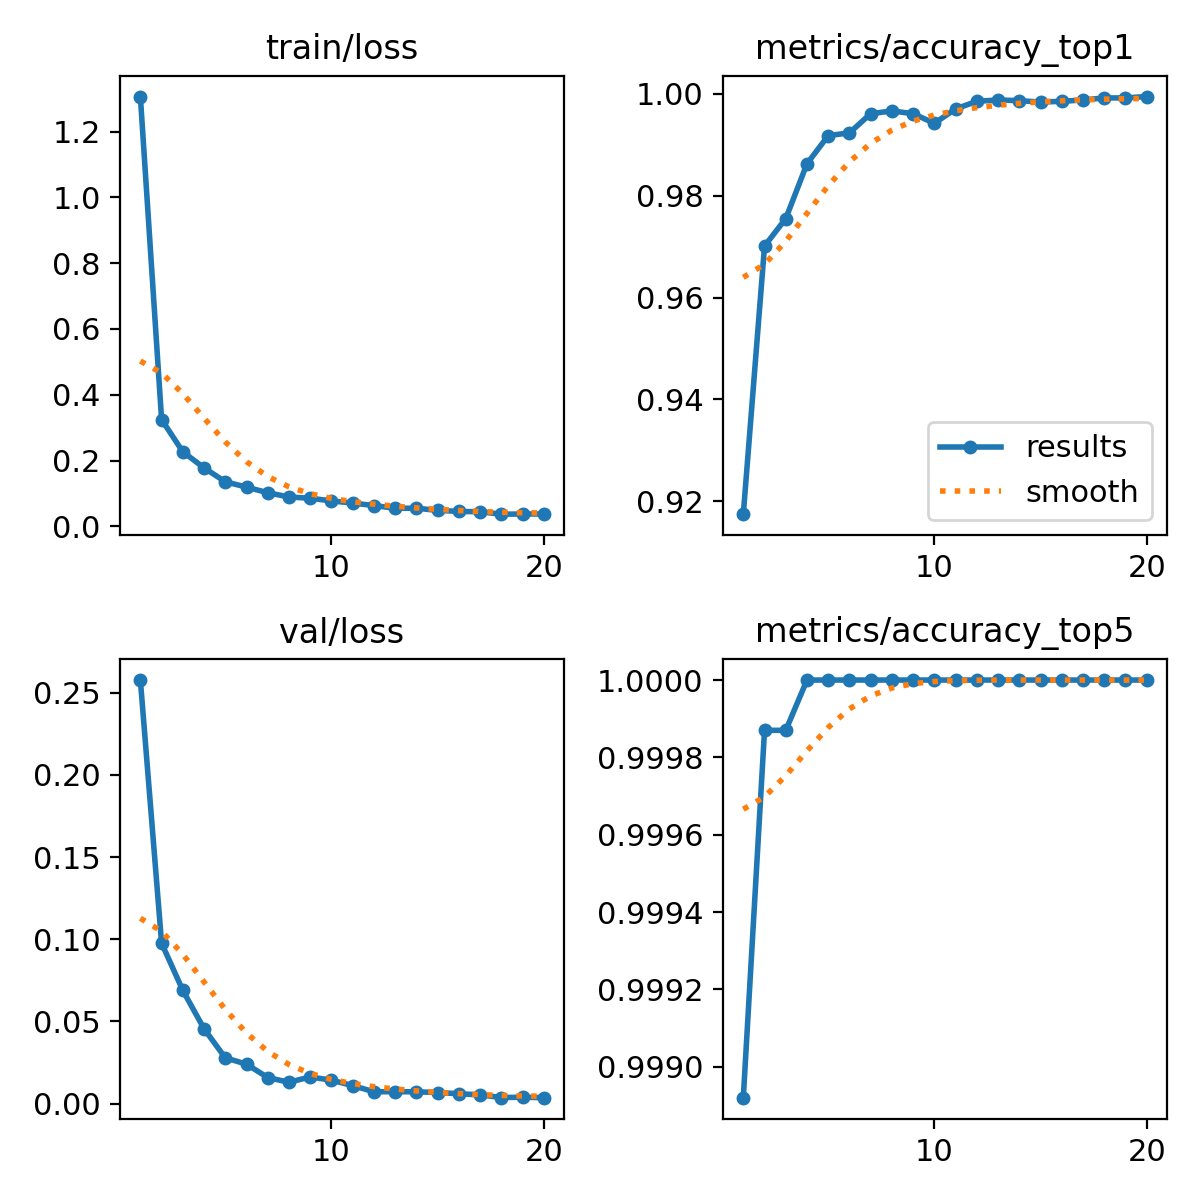



🎯 Confusion Matrix:



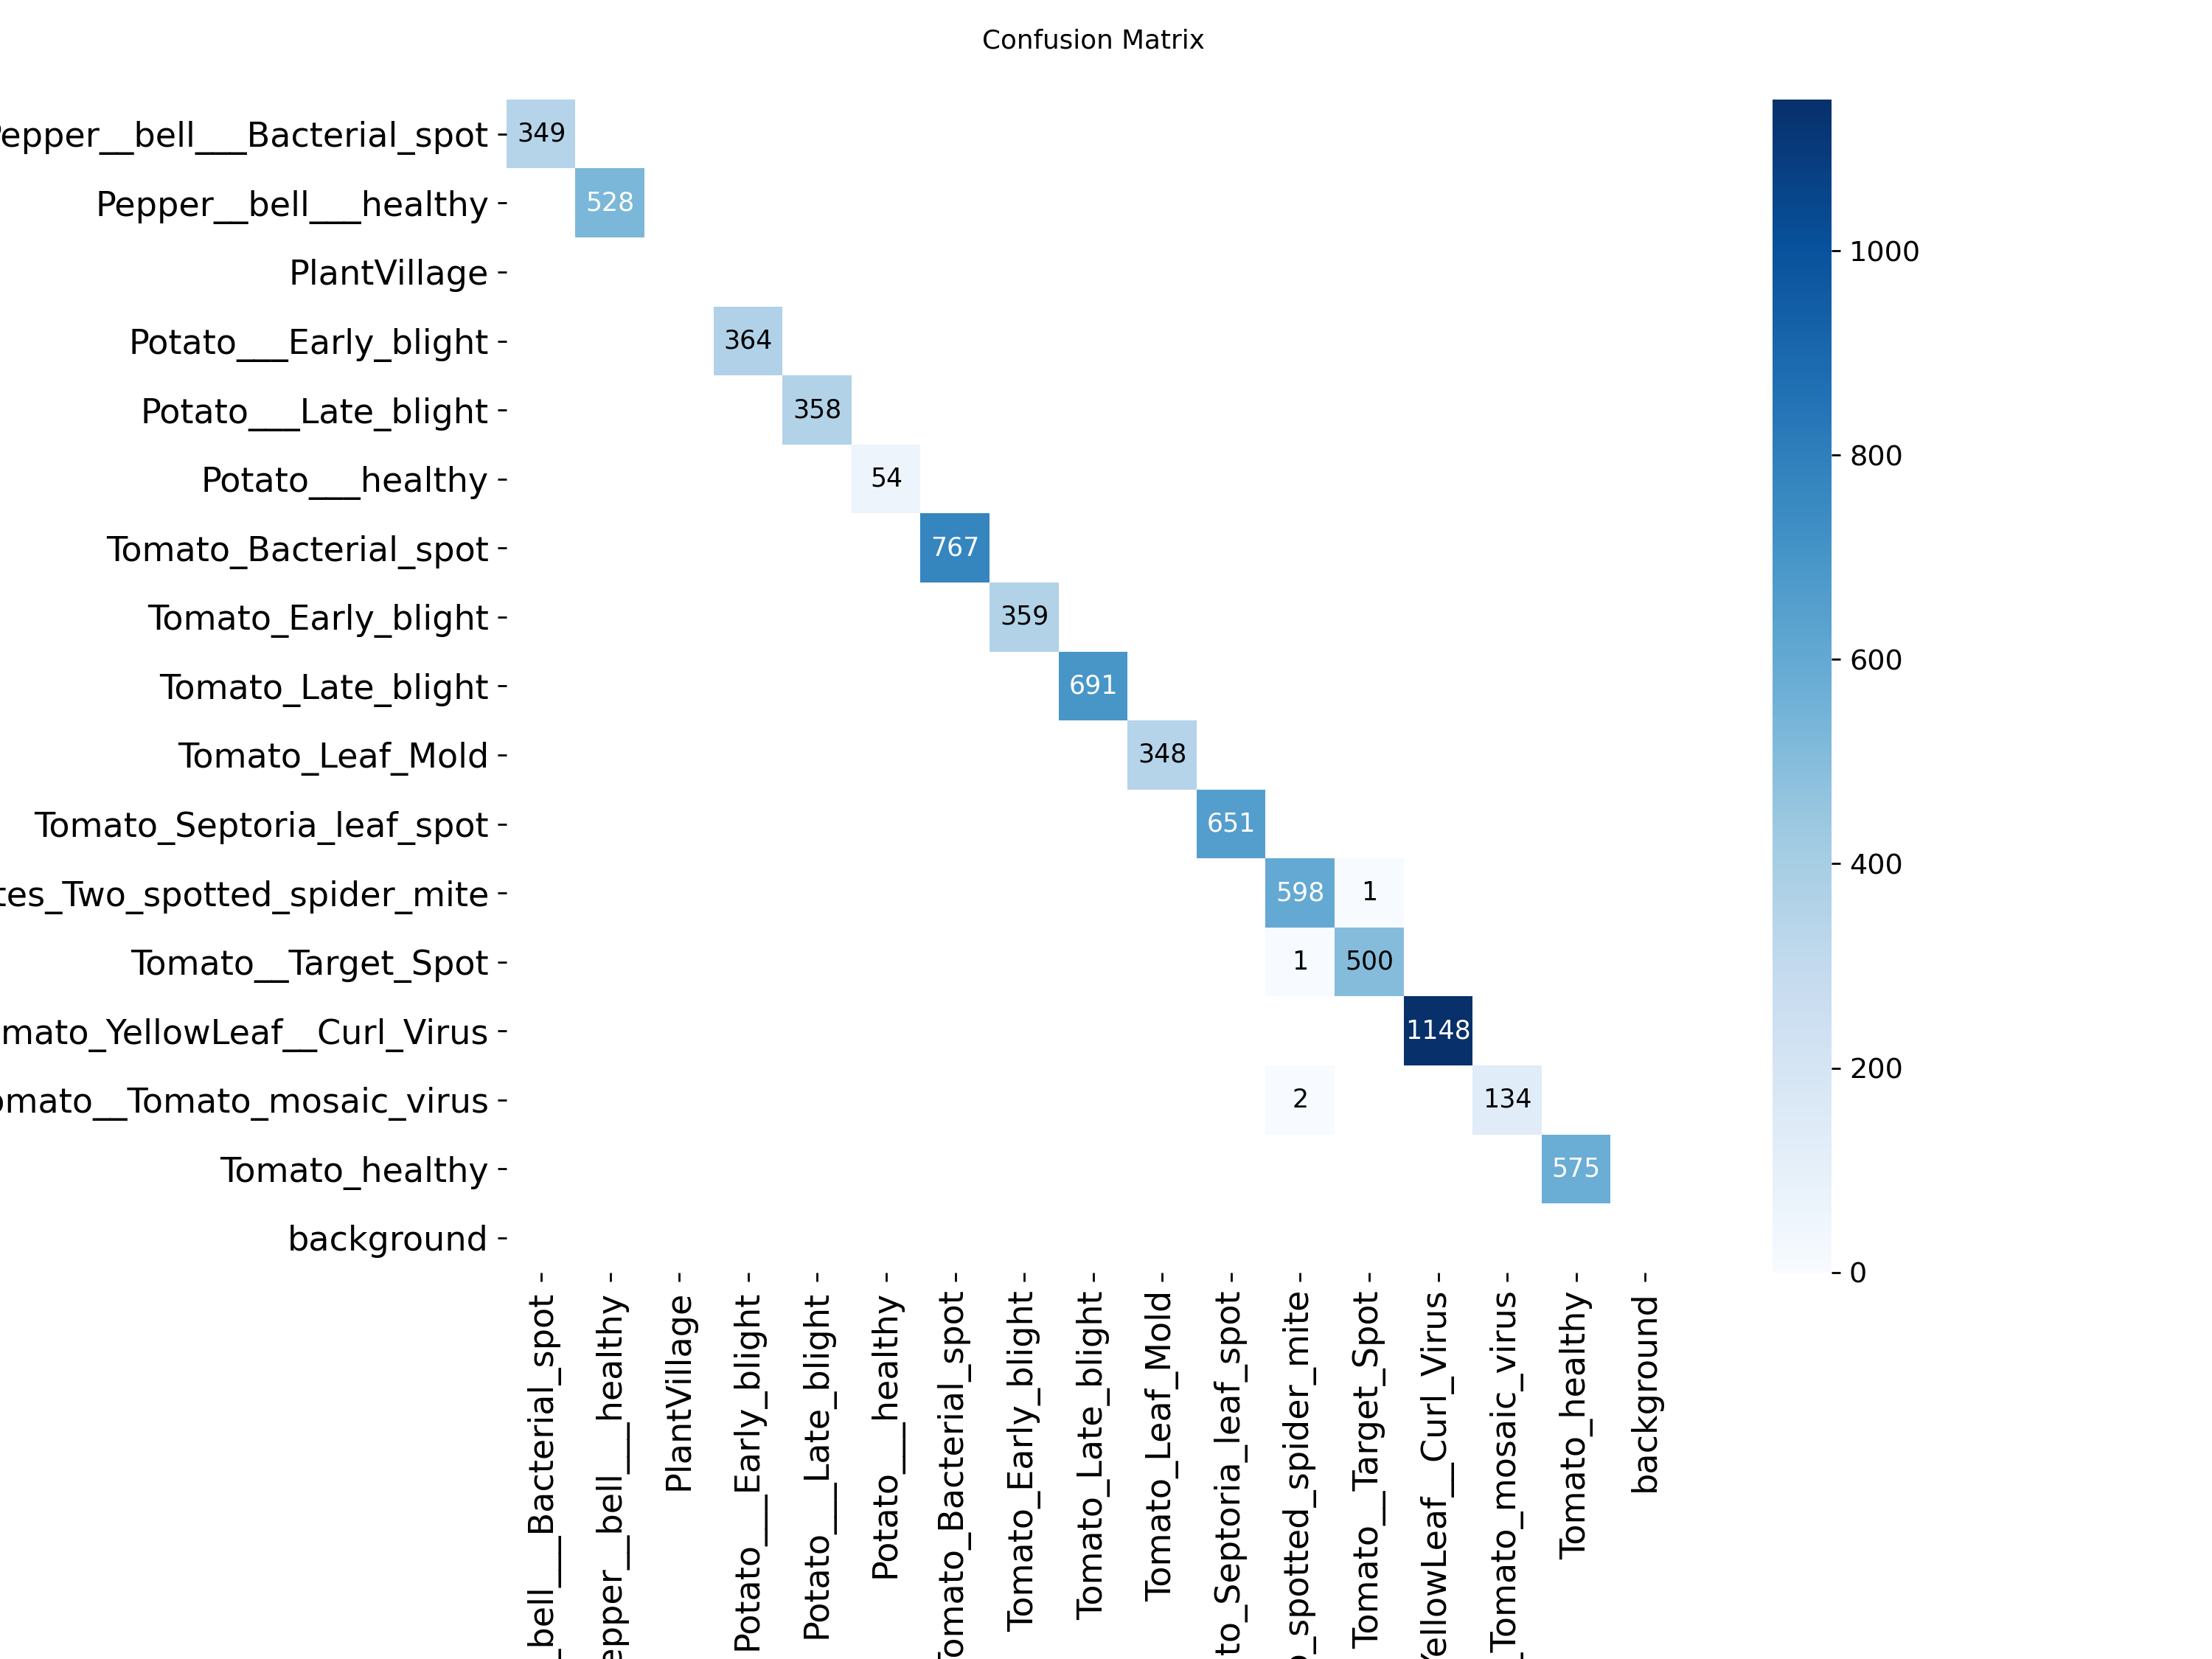

In [2]:
# Cell 2: View training performance graphs
from IPython.display import Image, display
import matplotlib.pyplot as plt

print("📈 Training Results:\n")

# Results graph (loss, accuracy curves)
results_path = 'runs/classify/plant_disease_v1/results.png'
if os.path.exists(results_path):
    display(Image(results_path))
else:
    print("❌ Results graph not found")

print("\n" + "="*50 + "\n")

# Confusion matrix (which diseases it confuses)
confusion_path = 'runs/classify/plant_disease_v1/confusion_matrix.png'
if os.path.exists(confusion_path):
    print("🎯 Confusion Matrix:\n")
    display(Image(confusion_path))
else:
    print("❌ Confusion matrix not found")

🖼️ Testing on: Tomato_Early_blight
Image: bbcccb3c-bcf2-4dc9-b2e2-6aecd86f52d5___RS_Erly.B 8370.JPG



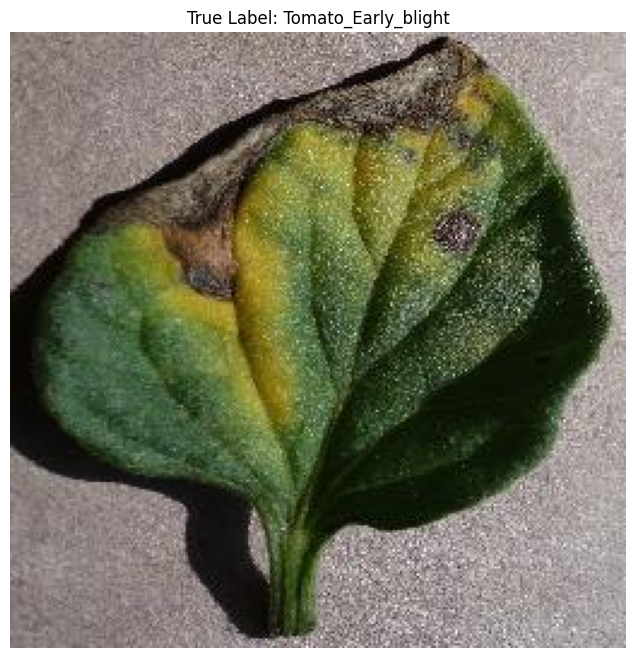

🎯 Top 3 Predictions:

1. Tomato_Early_blight                      100.00%
2. Tomato_Late_blight                         0.00%
3. Pepper__bell___Bacterial_spot              0.00%

✅ CORRECT!


In [3]:
# Cell 3: Test on a sample image
import random
from pathlib import Path
from PIL import Image as PILImage

# Get a random validation image
val_path = Path('datasets/plantvillage_yolo/val')
classes = [d for d in val_path.iterdir() if d.is_dir()]

if classes:
    # Pick random class
    random_class = random.choice(classes)
    
    # Pick random image from that class
    images = list(random_class.glob('*.jpg')) + list(random_class.glob('*.JPG'))
    
    if images:
        test_image = str(random.choice(images))
        print(f"🖼️ Testing on: {random_class.name}")
        print(f"Image: {Path(test_image).name}\n")
        
        # Display the image
        img = PILImage.open(test_image)
        plt.figure(figsize=(8, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"True Label: {random_class.name}")
        plt.show()
        
        # Predict
        results = model.predict(test_image, verbose=False)
        
        # Get top 3 predictions
        probs = results[0].probs
        top3_indices = probs.top5[:3]
        
        print("🎯 Top 3 Predictions:\n")
        for i, idx in enumerate(top3_indices, 1):
            class_name = model.names[idx]
            confidence = probs.data[idx].item() * 100
            print(f"{i}. {class_name:<40} {confidence:>6.2f}%")
        
        # Check if correct
        predicted_class = model.names[probs.top1]
        if predicted_class == random_class.name:
            print("\n✅ CORRECT!")
        else:
            print(f"\n❌ WRONG! Predicted: {predicted_class}")
    else:
        print("No images found in validation set")
else:
    print("Validation folder not found")